# Datenbereinigung für Datenbank Airbnb NYC

In diesem Notebook werden alle Schritte und Überlegungen im Projekt "Lineare Regression mit Airbnb-Daten" erarbeitet, die mit der Datenbank PostgreSQL zu tun haben. Dazu werden Spalten der Datei `listings.csv.gz` (Quelle: InsideAirbnb) aufbereitet, gelöscht, Features erstellt und Ansichten VIEWs entwickelt, die dann in csv-Dateien exportiert werden und in Pandas-Dataframes nutzbar sind. Dazu wurde vor allem auch die Darstellung auf Github bedacht und die sparsame Bereitstellung von (großen) Datenmengen.


Hinweis: Alle Vorgehensweisen und Code wurden mit Gemini entwickelt.

# 1. Tabelle in DB anlegen

#### a) Weg 1: Tabelle direkt im Query-tool von PGAdmin erstellen

```sql

CREATE TABLE nyc_airbnb_listings_raw (
    -- 1. IDENTIFIKATION UND LAGE
    id BIGINT PRIMARY KEY,
    city VARCHAR(50) NOT NULL, -- Flexibilität für weitere Städte (z.B. Berlin, Paris)
    latitude DOUBLE PRECISION NOT NULL,
    longitude DOUBLE PRECISION NOT NULL,

    -- 2. ZIELVARIABLE UND KATEGORIEN
    price NUMERIC(10, 2) NOT NULL,
    room_type VARCHAR(50) NOT NULL, 
    neighbourhood_group_cleansed VARCHAR(50), 
    
    -- 3. UNTERKUNFT-SPEZIFISCHE FEATURES
    accommodates INTEGER NOT NULL,
    bedrooms INTEGER,
    beds INTEGER,
    bathrooms NUMERIC(3, 1), -- Erlaubt halbe Badezimmer (z.B. 1.5)
    minimum_nights INTEGER NOT NULL,
    availability_365 INTEGER NOT NULL,

    -- 4. BINÄRE UND HOST-INFOS
    instant_bookable BOOLEAN NOT NULL,
    host_is_superhost BOOLEAN, 
    host_total_listings_count INTEGER,

    -- 5. BEWERTUNGEN
    review_scores_rating NUMERIC(4, 2) 
);

#### b) Weg 2: Tabelle aus dem Jupyter Notebook heraus anlegen

Schritte: Auslagerung SQL-Code aus a) in SQL-Dateien

- neuer Ordner im Projekt: SQL (OK)
- Datei 1 dort ablegen: `01_create_table.sql` (OK)
- Datei 2 dort ablegen: `02_create_view_NYC.sql` (OK)
- Verbindung zu Datenbank herstellen und Engine starten (Schritt 1 unten)
- Hilfsfunktionen zum Anzeigen und Einlesen von SQL-Dateien

Schritt 1: Verbindung zur Datenbank herstellen

Erklärung: 
- Datenbank (PostgreSQL/pgAdmin): Vergleich "verschlossenes Lagerhaus"
- `db_config.json`: "Ausweis" und "Schlüssel": Aus Sicherheitsgründen sind die Zugangsdaten in einem separaten .json-File.
- `create_engine`: Bau einer direkten Telefonleitung oder einer Schiene von Laptop (Jupyter Notebook) zu "Lagerhaus".
- `engine`: Das ist das "Telefon" selbst. Solange dieses Objekt im Notebook existiert, können Befehle gegeben und Daten geschickt werden.


In [1]:
import json
from sqlalchemy import create_engine
from sqlalchemy import text

# ---------------------------------------------
# SCHRITT A: Secrets aus der Konfigurationsdatei laden (Sicherheits-Layer)
# ---------------------------------------------
try:
    # Stellen Sie sicher, dass 'db_config.json' im gleichen Ordner wie das Notebook liegt
    with open('db_config.json', 'r') as f:
        config = json.load(f)
except FileNotFoundError:
    print("FEHLER: db_config.json nicht gefunden. Bitte prüfen Sie den Pfad.")
    # Platzhalter, falls die Datei nicht geladen werden kann (Bitte ersetzen!)
    config = {
        "DB_USER": "postgres",
        "DB_PASSWORD": "Ihr_Passwort", 
        "DB_NAME": "Airbnb",
        "DB_HOST": "localhost",
        "DB_PORT": "5432"
    }

# ---------------------------------------------
# SCHRITT B: Engine erstellen (SQLAlchemy)
# ---------------------------------------------

DB_USER = config['DB_USER']
DB_PASSWORD = config['DB_PASSWORD']
DB_HOST = config['DB_HOST']
DB_PORT = config['DB_PORT']
DB_NAME = config['DB_NAME']

# Erstellen der Engine/Verbindungszeichenkette
engine = create_engine(
    f'postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}'
)

print(f"✅ SQLAlchemy-Engine für Datenbank '{DB_NAME}' erfolgreich erstellt.")

✅ SQLAlchemy-Engine für Datenbank 'Airbnb' erfolgreich erstellt.


Schritt 2: Hilfsfunktionen

Die unten eingefügten Code-Zeilen mit den Funktionen `def get_sql_code` und `def display_sql_file` verweisen auf die .sql-files im Ordner SQL und stellen die Inhalte ordentlich dar (`display`).

In [94]:
# Funktion zum Einlesen der SQL-Datei
def get_sql_code(path):
    with open(path, 'r', encoding='utf-8') as f:
        return f.read()

# Pfad zu deiner Datei (.. geht einen Ordner hoch aus 'notebooks' in 'sql')
table_sql = get_sql_code('../sql/01_create_table.sql')

# Anzeige im Notebook (formatiert)
from IPython.display import Markdown
Markdown(f"### Verwendetes Datenbankschema\n```sql\n{table_sql}\n```")

### Verwendetes Datenbankschema
```sql
-- Tabelle Erstellen für NYC in PGAdmin

DROP TABLE IF EXISTS nyc_airbnb_listings_raw CASCADE;

CREATE TABLE chaicago_airbnb_listings_raw (
    -- 1. IDENTIFIKATION UND LAGE
    id BIGINT PRIMARY KEY,
    city VARCHAR(50) NOT NULL, -- Flexibilität für weitere Städte (z.B. Berlin, Paris)
    latitude DOUBLE PRECISION NOT NULL,
    longitude DOUBLE PRECISION NOT NULL,

    -- 2. ZIELVARIABLE UND KATEGORIEN
    price NUMERIC(10, 2) NOT NULL,
    room_type VARCHAR(50) NOT NULL, 
    neighbourhood_group_cleansed VARCHAR(50), 
    
    -- 3. UNTERKUNFT-SPEZIFISCHE FEATURES
    accommodates INTEGER NOT NULL,
    bedrooms INTEGER,
    beds INTEGER,
    bathrooms NUMERIC(3, 1), -- Erlaubt halbe Badezimmer (z.B. 1.5)
    minimum_nights INTEGER NOT NULL,
    availability_365 INTEGER NOT NULL,

    -- 4. BINÄRE UND HOST-INFOS
    instant_bookable BOOLEAN NOT NULL,
    host_is_superhost BOOLEAN, 
    host_total_listings_count INTEGER,

    -- 5. BEWERTUNGEN
    review_scores_rating NUMERIC(4, 2) 
);
```

In [95]:
# Hilfsfunktion zum Anzeigen von SQL-Dateien im Notebook
def display_sql_file(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        sql_code = f.read()
    print(f"--- Inhalt von {file_path} ---")
    # Markdown-Anzeige für schönes Syntax-Highlighting
    from IPython.display import Markdown
    return Markdown(f"```sql\n{sql_code}\n```")

# Aufruf der Dateien
display_sql_file('../sql/01_create_table.sql')

--- Inhalt von ../sql/01_create_table.sql ---


```sql
-- Tabelle Erstellen für NYC in PGAdmin

DROP TABLE IF EXISTS nyc_airbnb_listings_raw CASCADE;

CREATE TABLE chaicago_airbnb_listings_raw (
    -- 1. IDENTIFIKATION UND LAGE
    id BIGINT PRIMARY KEY,
    city VARCHAR(50) NOT NULL, -- Flexibilität für weitere Städte (z.B. Berlin, Paris)
    latitude DOUBLE PRECISION NOT NULL,
    longitude DOUBLE PRECISION NOT NULL,

    -- 2. ZIELVARIABLE UND KATEGORIEN
    price NUMERIC(10, 2) NOT NULL,
    room_type VARCHAR(50) NOT NULL, 
    neighbourhood_group_cleansed VARCHAR(50), 
    
    -- 3. UNTERKUNFT-SPEZIFISCHE FEATURES
    accommodates INTEGER NOT NULL,
    bedrooms INTEGER,
    beds INTEGER,
    bathrooms NUMERIC(3, 1), -- Erlaubt halbe Badezimmer (z.B. 1.5)
    minimum_nights INTEGER NOT NULL,
    availability_365 INTEGER NOT NULL,

    -- 4. BINÄRE UND HOST-INFOS
    instant_bookable BOOLEAN NOT NULL,
    host_is_superhost BOOLEAN, 
    host_total_listings_count INTEGER,

    -- 5. BEWERTUNGEN
    review_scores_rating NUMERIC(4, 2) 
);
```

Schritt 3: Den Bauplan aus dem Notebook an die DB senden

- Nutzung des engine ("Telefonleitung"), um den Inhalt der Datei `01_create_table.sql` direkt aus dem Notebook an die Datenbank zu schicken statt direkt im Query-Tool.

In [ ]:
# 1. Wir laden den Inhalt der Datei in eine Variable
sql_befehl = get_sql_code('../sql/01_create_table.sql')

# 2.'with engine.connect()' öffnet kurz die Leitung und schließt sie danach wieder
with engine.connect() as connection:
    # Wir sagen der Datenbank: "Führe diesen Text aus!"
    connection.execute(text(sql_befehl))
    print("Die Tabelle wurde in der Datenbank angelegt!")

Die Tabelle wurde in der Datenbank angelegt!


## 2. Datenaufbereitung für DB

Rohdaten zu NYC von *Inside Airbnb*

In [97]:
import pandas as pd

In [98]:
import sys
import os

# Definiert den relativen Pfad zum 'src' Ordner
# .. = Ein Ordner hoch zum Projekt-Root
# /src = Dann in den Ordner src
src_path = os.path.join(os.getcwd(), '..', 'src')

# Fügt diesen Pfad dem Python-Suchpfad hinzu
if src_path not in sys.path:
    sys.path.append(src_path)

print(f"✅ src-Ordner temporär zum Suchpfad hinzugefügt: {src_path}")

✅ src-Ordner temporär zum Suchpfad hinzugefügt: c:\Users\Annette\Data_Science\02_data-analytics\05_regression_projekt_airbnb\notebooks\..\src


In [99]:
df = pd.read_csv("../data/raw/listings_Chicago_raw.csv")

In [100]:
df.shape

(8660, 79)

In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8660 entries, 0 to 8659
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            8660 non-null   int64  
 1   listing_url                                   8660 non-null   object 
 2   scrape_id                                     8660 non-null   int64  
 3   last_scraped                                  8660 non-null   object 
 4   source                                        8660 non-null   object 
 5   name                                          8660 non-null   object 
 6   description                                   8498 non-null   object 
 7   neighborhood_overview                         4731 non-null   object 
 8   picture_url                                   8660 non-null   object 
 9   host_id                                       8660 non-null   i

#### Fehlende Werte im Datensatz prüfen

In [102]:
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

description                      162
neighborhood_overview           3929
host_name                        618
host_since                       618
host_location                   2357
host_about                      3733
host_response_time              1166
host_response_rate              1166
host_acceptance_rate            1052
host_is_superhost                289
host_thumbnail_url               618
host_picture_url                 618
host_neighbourhood               815
host_listings_count              618
host_total_listings_count        618
host_verifications               618
host_has_profile_pic             618
host_identity_verified           618
neighbourhood                   3929
neighbourhood_group_cleansed    8660
bathrooms                        785
bathrooms_text                    39
bedrooms                         187
beds                             785
price                            835
minimum_minimum_nights             6
maximum_minimum_nights             6
m

In [103]:
df['price'].isnull().sum()

np.int64(835)

In [60]:
df.shape

(8660, 79)

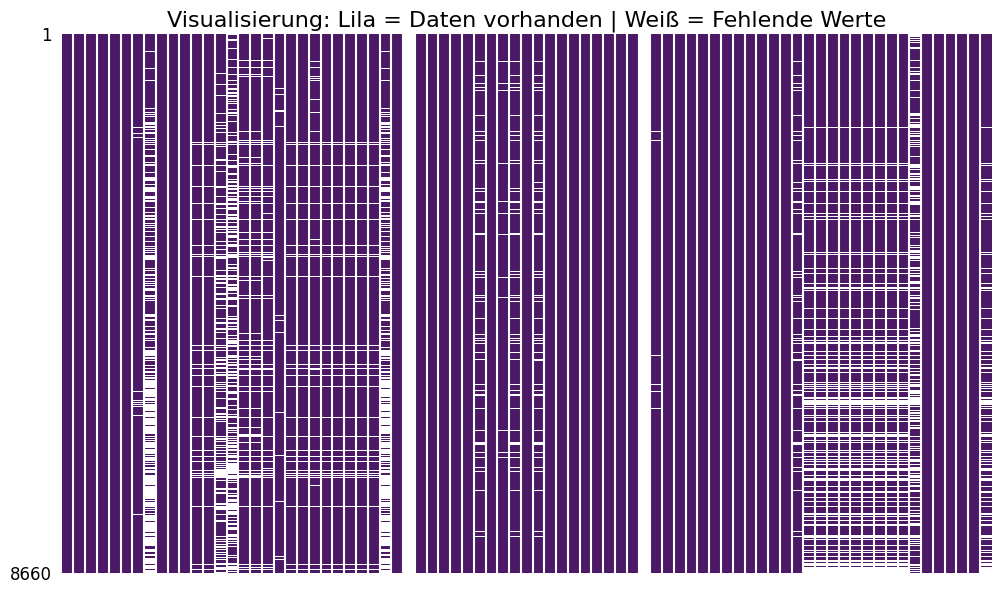

In [104]:
import missingno as msno
import matplotlib.pyplot as plt

# 1. Eine Grafik-Figur erstellen
fig, ax = plt.subplots(figsize=(12, 7))

# 2. Die Matrix zeichnen (Lila für vorhandene Daten)
# color=(0.3, 0.1, 0.4) ist das dunkle Lila
msno.matrix(df, ax=ax, color=(0.3, 0.1, 0.4), sparkline=False, fontsize=10)

plt.title("Visualisierung: Lila = Daten vorhanden | Weiß = Fehlende Werte", fontsize=16)
plt.show()

In [105]:
print(df.columns.tolist())
#print("-" * 50)

['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'calendar_updated', 'has_availability', 'availability_30', 'availability_60', 'availability_90', 'availabil

## Schritt 1: Spalten reduzieren

In [106]:
SQL_COLUMNS = [
    'id',
    'price',
    'accommodates',
    'room_type',
    'bedrooms',
    'beds',
    'bathrooms',  
    'neighbourhood_group_cleansed',
    'minimum_nights',
    'instant_bookable',
    'review_scores_rating',
    'host_is_superhost',
    'host_total_listings_count',
    'availability_365',
    'latitude',
    'longitude'

]

df1 = df[SQL_COLUMNS].copy()

In [107]:
df1.head()


,id,price,accommodates,room_type,bedrooms,beds,bathrooms,neighbourhood_group_cleansed,minimum_nights,instant_bookable,review_scores_rating,host_is_superhost,host_total_listings_count,availability_365,latitude,longitude
0,2384,$119.00,1,Private room,1.0,1.0,1.0,NaN,3,f,4.99,f,1.0,348,41.787900,-87.587800
1,7126,$89.00,2,Entire home/apt,1.0,1.0,1.0,NaN,2,f,4.73,t,2.0,302,41.901660,-87.680210
2,10945,$203.00,4,Entire home/apt,2.0,2.0,1.0,NaN,4,t,4.74,t,87.0,325,41.911960,-87.639810
3,12140,$339.00,3,Private room,1.0,1.0,1.0,NaN,2,f,4.95,f,1.0,156,41.923570,-87.649470
4,28749,$258.00,6,Entire home/apt,3.0,3.0,2.0,NaN,2,f,4.83,t,7.0,74,41.920226,-87.679613


In [108]:
df1.tail()

,id,price,accommodates,room_type,bedrooms,beds,bathrooms,neighbourhood_group_cleansed,minimum_nights,instant_bookable,review_scores_rating,host_is_superhost,host_total_listings_count,availability_365,latitude,longitude
8655,1513821766801636584,$900.00,4,Entire home/apt,2.0,2.0,1.0,NaN,32,f,NaN,NaN,70.0,275,41.93292,-87.64610
8656,1514427498735918146,$99.00,4,Entire home/apt,3.0,3.0,1.0,NaN,32,f,NaN,f,2.0,365,41.76730,-87.61189
8657,1514602729230425948,$559.00,16,Entire home/apt,6.0,10.0,4.0,NaN,1,f,NaN,f,6.0,365,41.82241,-87.62109
8658,1514621681093690520,$559.00,16,Entire home/apt,6.0,10.0,4.0,NaN,1,t,NaN,f,6.0,365,41.82149,-87.62028
8659,1514812314516488457,$68.00,8,Entire home/apt,3.0,3.0,1.0,NaN,38,f,NaN,f,1.0,171,41.85207,-87.67918


## Schritt 2: Zeilen ohne Preis entfernen und Datentyp anpassen

In [109]:
df2 = df1.dropna(subset=['price']).copy()
print(f"Zeilen nach der Preislöschung: {len(df2)}")

Zeilen nach der Preislöschung: 7825


In [110]:
# 1. Entfernen von Währungszeichen ($), Kommas (,) und Leerzeichen
df2['price'] = df2['price'].astype(str).str.replace(r'[$,\s]', '', regex=True)

# 2. Konvertieren zu numerischem Float
# Wichtig: errors='coerce' verwandelt Einträge, die nicht konvertiert werden können (z.B. leere Zellen, 'N/A'), in NaN.
df2['price'] = pd.to_numeric(df2['price'], errors='coerce')

# 3b. NEU: Nachbereinigung, falls 'coerce' neue NaN-Werte erzeugt hat
rows_before = len(df2)
df2.dropna(subset=['price'], inplace=True)
rows_after = len(df2)

if rows_before > rows_after:
    print(f"⚠️ ACHTUNG: {rows_before - rows_after} Zeilen wurden nach der String-Bereinigung entfernt, da sie nicht numerisch waren.")
    print(f"Neue Zeilenanzahl: {rows_after}")

## Schritt 3: Binare Spalten konvertieren

Spalten: instant_bookable, host_is_superhost

In [111]:
from IPython.display import display
display(df2[['instant_bookable', 'host_is_superhost']].head(20))

,instant_bookable,host_is_superhost
0,f,f
1,f,t
2,t,t
3,f,f
4,f,t
5,f,t
6,f,t
7,f,t
8,f,t
9,f,t


In [112]:
unique_values = df2['instant_bookable'].unique()
print("Eindeutige Werte in 'instant_bookable':", unique_values)
print("--- Vollständige Verteilung in 'instant_bookable' (t, f, NaN) ---")
print(df2['instant_bookable'].value_counts(dropna=False))

Eindeutige Werte in 'instant_bookable': ['f' 't']
--- Vollständige Verteilung in 'instant_bookable' (t, f, NaN) ---
instant_bookable
f    4912
t    2913
Name: count, dtype: int64


In [113]:
unique_values1 = df2['host_is_superhost'].unique()
print("Eindeutige Werte in 'host_is_superhost':", unique_values1)
print("--- Vollständige Verteilung in 'host_is_superhost' (t, f, NaN) ---")
print(df2['host_is_superhost'].value_counts(dropna=False))

Eindeutige Werte in 'host_is_superhost': ['f' 't' nan]
--- Vollständige Verteilung in 'host_is_superhost' (t, f, NaN) ---
host_is_superhost
f      3951
t      3603
NaN     271
Name: count, dtype: int64


a) Umwandlung von 'instant_bookable' in booleschen Typ

In [114]:
 # MAPPING: 't' und 'f' auf True und False mappen
boolean_mapping = {'t': True, 'f': False}

# KONVERTIERUNG: Die .map-Funktion wendet das Dictionary an
# und behält gleichzeitig alle NaN-Werte bei, was gut ist für Spalten, 
# die NULL zulassen (wie host_is_superhost).
df2['instant_bookable'] = df2['instant_bookable'].map(boolean_mapping)

# PRÜFUNG: Kontrolle, welche Werte jetzt vorhanden sind
print("Eindeutige Werte in 'instant_bookable':")
print(df2['instant_bookable'].value_counts(dropna=False))

Eindeutige Werte in 'instant_bookable':
instant_bookable
False    4912
True     2913
Name: count, dtype: int64


b) Umwandlung von 'host_is_superhost' in Boolean

In [115]:
# MAPPING: 't' und 'f' auf True und False mappen
boolean_mapping1 = {'t': True, 'f': False}

# KONVERTIERUNG: Die .map-Funktion wendet das Dictionary an
# und behält gleichzeitig alle NaN-Werte bei, was gut ist für Spalten, 
# die NULL zulassen.
df2['host_is_superhost'] = df2['host_is_superhost'].map(boolean_mapping1)

# PRÜFUNG: Kontrolle, welche Werte jetzt vorhanden sind
print("Eindeutige Werte in 'host_is_superhost':")
print(df2['host_is_superhost'].value_counts(dropna=False))

Eindeutige Werte in 'host_is_superhost':
host_is_superhost
False    3951
True     3603
NaN       271
Name: count, dtype: int64


## Schritt 4: Spalte 'city' ergänzen

In [116]:
df2['city'] = 'Chicago'
print("--- Die ersten Zeilen mit der neuen 'city'-Spalte ---")
print(df2[['city', 'price', 'instant_bookable', 'host_is_superhost']].head())

--- Die ersten Zeilen mit der neuen 'city'-Spalte ---
      city  price  instant_bookable host_is_superhost
0  Chicago  119.0             False             False
1  Chicago   89.0             False              True
2  Chicago  203.0              True              True
3  Chicago  339.0             False             False
4  Chicago  258.0             False              True


## Schritt 5: Bathrooms bereinigen

In [117]:
df2['bathrooms'].unique()

array([ 1. ,  2. ,  1.5,  3. ,  2.5,  3.5,  4. ,  0. ,  0.5,  4.5,  5. ,
        6.5,  5.5,  6. ,  7. ,  9. ,  7.5,  8. ,  8.5, 17. ,  nan, 10. ,
       12. , 15. ])

In [118]:
df2['bathrooms'].isnull().sum()

np.int64(3)

In [119]:
df2['bathrooms'] = pd.to_numeric(df2['bathrooms'], errors='coerce')
print(f"Datentyp von 'bathrooms' nach Konvertierung: {df2['bathrooms'].dtype}")

Datentyp von 'bathrooms' nach Konvertierung: float64


## Schritt 6: Finale Überprüfung vor Einpflege in die DB

In [120]:
df2.shape

(7825, 17)

In [121]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7825 entries, 0 to 8659
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            7825 non-null   int64  
 1   price                         7825 non-null   float64
 2   accommodates                  7825 non-null   int64  
 3   room_type                     7825 non-null   object 
 4   bedrooms                      7819 non-null   float64
 5   beds                          7824 non-null   float64
 6   bathrooms                     7822 non-null   float64
 7   neighbourhood_group_cleansed  0 non-null      float64
 8   minimum_nights                7825 non-null   int64  
 9   instant_bookable              7825 non-null   bool   
 10  review_scores_rating          6347 non-null   float64
 11  host_is_superhost             7554 non-null   object 
 12  host_total_listings_count     7233 non-null   float64
 13  availabi

In [122]:
df2['neighbourhood_group_cleansed'] = df2['neighbourhood_group_cleansed'].fillna('undefined')

In [123]:
df2['neighbourhood_group_cleansed'].isnull().sum()

np.int64(0)

In [132]:
df2['neighbourhood_group_cleansed'].dtype

dtype('O')

[Data Dictionary](https://docs.google.com/spreadsheets/d/116R-QwHH8gGSLItQV7PPvEJBxDXbEOxg93yDzJYcNHY/edit?gid=0#gid=0)


## Schritt 7: Export in Ordner Data/interim

In [124]:
import os

# 1. Definieren des Zielpfads
base_path = r'C:\Users\Annette\Data_Science\02_data-analytics\05_regression_projekt_airbnb\data'
file_name = 'chicago_airbnb_prepared_for_sql.csv'
target_folder = 'interim'

# Den vollständigen Pfad erstellen (nutzt os.path.join für korrekte Schrägstriche)
full_path = os.path.join(base_path, target_folder, file_name)

# 2. Export des DataFrames
# index=False ist WICHTIG, damit Pandas die Zeilennummern (den Index) 
# NICHT als zusätzliche Spalte in die CSV-Datei schreibt.
df2.to_csv(full_path, index=False)

print("--- Export-Bestätigung ---")
print(f"✅ DataFrame wurde erfolgreich exportiert nach:")
print(full_path)

--- Export-Bestätigung ---
✅ DataFrame wurde erfolgreich exportiert nach:
C:\Users\Annette\Data_Science\02_data-analytics\05_regression_projekt_airbnb\data\interim\chicago_airbnb_prepared_for_sql.csv


In [133]:
df_check = pd.read_csv("../data/interim/chicago_airbnb_prepared_for_sql.csv")

In [126]:
df_check.head()

,id,price,accommodates,room_type,bedrooms,beds,bathrooms,neighbourhood_group_cleansed,minimum_nights,instant_bookable,review_scores_rating,host_is_superhost,host_total_listings_count,availability_365,latitude,longitude,city
0,2384,119.0,1,Private room,1.0,1.0,1.0,undefined,3,False,4.99,False,1.0,348,41.787900,-87.587800,Chicago
1,7126,89.0,2,Entire home/apt,1.0,1.0,1.0,undefined,2,False,4.73,True,2.0,302,41.901660,-87.680210,Chicago
2,10945,203.0,4,Entire home/apt,2.0,2.0,1.0,undefined,4,True,4.74,True,87.0,325,41.911960,-87.639810,Chicago
3,12140,339.0,3,Private room,1.0,1.0,1.0,undefined,2,False,4.95,False,1.0,156,41.923570,-87.649470,Chicago
4,28749,258.0,6,Entire home/apt,3.0,3.0,2.0,undefined,2,False,4.83,True,7.0,74,41.920226,-87.679613,Chicago


In [134]:
df_check.columns.tolist()

['id',
 'price',
 'accommodates',
 'room_type',
 'bedrooms',
 'beds',
 'bathrooms',
 'neighbourhood_group_cleansed',
 'minimum_nights',
 'instant_bookable',
 'review_scores_rating',
 'host_is_superhost',
 'host_total_listings_count',
 'availability_365',
 'latitude',
 'longitude',
 'city']

## Schritt 8: Export in DB

In [135]:
import json
from sqlalchemy import create_engine

# ---------------------------------------------
# SCHRITT A: Secrets aus der Konfigurationsdatei laden (Sicherheits-Layer)
# ---------------------------------------------
try:
    # 'db_config.json' muss im gleichen Ordner liegen wie das Notebook
    with open('db_config.json', 'r') as f:
        config = json.load(f)
except FileNotFoundError:
    print("FEHLER: db_config.json nicht gefunden. Bitte prüfen Sie den Pfad.")
    # Platzhalter, falls die Datei nicht geladen werden kann 
    config = {
        "DB_USER": "postgres",
        "DB_PASSWORD": "Ihr_Passwort", 
        "DB_NAME": "Airbnb",
        "DB_HOST": "localhost",
        "DB_PORT": "5432"
    }

# ---------------------------------------------
# SCHRITT B: Engine erstellen (SQLAlchemy)
# ---------------------------------------------

DB_USER = config['DB_USER']
DB_PASSWORD = config['DB_PASSWORD']
DB_HOST = config['DB_HOST']
DB_PORT = config['DB_PORT']
DB_NAME = config['DB_NAME']

# Erstellen der Engine/Verbindungszeichenkette
engine = create_engine(
    f'postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}'
)

print(f"✅ SQLAlchemy-Engine für Datenbank '{DB_NAME}' erfolgreich erstellt.")

✅ SQLAlchemy-Engine für Datenbank 'Airbnb' erfolgreich erstellt.


In [136]:
# Definieren des Zieltabellennamens in der Datenbank
TABLE_NAME = 'chicago_airbnb_listings_raw'

# Importieren des DataFrames in die Datenbank
# if_exists='replace': Löscht die Tabelle, falls sie existiert, und erstellt sie neu.
# index=False: Verhindert, dass der Pandas-Index als Spalte importiert wird.
try:
    df2.to_sql(
        name=TABLE_NAME, 
        con=engine, 
        if_exists='replace', 
        index=False,
        chunksize=10000 # Importiert in Blöcken für bessere Performance
    )
    print(f"✅ Daten erfolgreich in die Tabelle '{TABLE_NAME}' in der Datenbank '{DB_NAME}' importiert.")

except Exception as e:
    print(f"❌ FEHLER beim Import. Bitte überprüfen Sie:")
    print(f"1. Ist der PostgreSQL-Server aktiv?")
    print(f"2. Ist der Tabellenname '{TABLE_NAME}' korrekt?")
    print(f"Fehlerdetails: {e}")

✅ Daten erfolgreich in die Tabelle 'chicago_airbnb_listings_raw' in der Datenbank 'Airbnb' importiert.


In [88]:
engine.dispose()
print("✅ SQLAlchemy Engine und alle verbundenen Ressourcen geschlossen.")

✅ SQLAlchemy Engine und alle verbundenen Ressourcen geschlossen.


# 2. VIEW erstellen für Lineare Regression

In [89]:
import pandas as pd

In [131]:
df = pd.read_csv("../data/interim/Chicago_airbnb_prepared_for_sql.csv")

#### View NYC

Eine SQL-View wird in PostgreSQL erstellt, um die Feature-Selection und Distanzberechnungen durchzuführen (Haversine erkennbar an 6371 (Erdradius), Angabe in km)

```sql
CREATE VIEW vw_airbnb_model_data AS
SELECT 
    id,
    neighbourhood_group_cleansed,
    room_type,
    instant_bookable,
    accommodates,
    bathrooms,
    bedrooms,
    beds,
    host_total_listings_count,
    -- Berechnung der Distanz zum Times Square (Haversine-Formel)
    (6371 * acos(
        cos(radians(40.7580)) * cos(radians(latitude)) * cos(radians(longitude) - radians(-73.9855)) + 
        sin(radians(40.7580)) * sin(radians(latitude))
    )) AS distance_to_center,
    price,
    LN(price + 1) AS ln_price
FROM nyc_airbnb_listings_raw
WHERE price > 0 
  AND price <= 564;
```

#### VIEW Chicago

```sql
CREATE VIEW vw_airbnb_chicago_model_data AS
SELECT 
    id,
    neighbourhood_cleansed, -- In Chicago gibt es keine 'Groups' (Boroughs) wie in NYC
    room_type,
    instant_bookable,
    accommodates,
    bathrooms,
    bedrooms,
    beds,
    host_total_listings_count,
    -- Berechnung der Distanz zum Millennium Park, Chicago (Haversine-Formel)
    (6371 * acos(
        cos(radians(41.8827)) * cos(radians(latitude)) * cos(radians(longitude) - radians(-87.6233)) + 
        sin(radians(41.8827)) * sin(radians(latitude))
    )) AS distance_to_center,
    price,
    LN(price + 1) AS ln_price
FROM chicago_airbnb_listings_raw
WHERE price > 0 
  AND price <= 500; -- Der Filterwert sollte ggf. an das Preisgefüge in Chicago angepasst werden
```


### Daten aus der VIEW in ein .csv laden und lokal abspeichern

In [16]:
import pandas as pd
from sqlalchemy import create_engine, text
import json
import os

# 1. Konfiguration laden (Schritt 1 ersetzt durch JSON)
try:
    with open('db_config.json', 'r') as f:
        config = json.load(f)

    # Verbindung herstellen mit f-String
    engine = create_engine(
        f"postgresql://{config['DB_USER']}:{config['DB_PASSWORD']}@{config['DB_HOST']}:{config['DB_PORT']}/{config['DB_NAME']}"
    )
    print("✅ Verbindungskonfiguration geladen.")

    # 2. VIEW aufrufen und als DataFrame laden
    query = "SELECT * FROM vw_airbnb_model_data;"
    
    with engine.connect() as connection:
        df_model = pd.read_sql(text(query), connection)
    
    print(f"✅ {len(df_model)} Zeilen aus der View geladen.")

    # 3. Als .csv im passenden Ordner speichern
    output_dir = "../data/processed"
    os.makedirs(output_dir, exist_ok=True)
    
    file_path = os.path.join(output_dir, "airbnb_NYC_model_data.csv")
    df_model.to_csv(file_path, index=False)

    print(f"💾 Datei erfolgreich gespeichert: {file_path}")

except FileNotFoundError:
    print("❌ Fehler: Die Datei 'db_config.json' wurde nicht gefunden!")
except Exception as e:
    print(f"❌ Ein Fehler ist aufgetreten: {e}")

✅ Verbindungskonfiguration geladen.
✅ 19808 Zeilen aus der View geladen.
💾 Datei erfolgreich gespeichert: ../data/processed\airbnb_NYC_model_data.csv


### Testaufruf der .csv-Datei in dataframe

In [17]:
df = pd.read_csv('../data/processed/airbnb_NYC_model_data.csv')

In [18]:
df.head

<bound method NDFrame.head of                         id neighbourhood_group_cleansed        room_type  \
0                 40824219                       Queens     Private room   
1                 40839416                    Manhattan     Private room   
2                 40843980                       Queens  Entire home/apt   
3                 40824301                     Brooklyn     Private room   
4                 40825740                     Brooklyn  Entire home/apt   
...                    ...                          ...              ...   
19803  1518145740023617475                    Manhattan  Entire home/apt   
19804  1518194647322488321                    Manhattan  Entire home/apt   
19805  1518232643177537314                    Manhattan  Entire home/apt   
19806  1518345023898568625                    Manhattan  Entire home/apt   
19807  1518352509290380578                    Manhattan  Entire home/apt   

       instant_bookable  accommodates  bathrooms  bedroom